In [7]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [8]:
DATASET_PATH = "/Users/dhanaraj/Downloads/Rubrik_Assignment/interview-assignment_Rubrik/dataset"

print(os.path.exists(DATASET_PATH))

True


In [9]:
folders = [
    f for f in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, f))
]

print("Total meetings:", len(folders))
print("First meeting folder:", folders[0])

Total meetings: 100
First meeting folder: 01KQ7F58A2E07B857C24624D


In [10]:
sample_folder = folders[0]
sample_path = os.path.join(DATASET_PATH, sample_folder)

with open(os.path.join(sample_path, "meeting-info.json")) as f:
    meeting_info = json.load(f)

with open(os.path.join(sample_path, "summary.json")) as f:
    summary = json.load(f)

with open(os.path.join(sample_path, "transcript.json")) as f:
    transcript = json.load(f)

print(meeting_info.keys())
print(summary.keys())
print(transcript.keys())

dict_keys(['meetingId', 'title', 'organizerEmail', 'host', 'startTime', 'endTime', 'duration', 'allEmails', 'invitees'])
dict_keys(['summary', 'actionItems', 'topics', 'overallSentiment', 'sentimentScore', 'keyMoments', 'meetingId'])
dict_keys(['data'])


In [11]:
rows = []

for folder in folders:
    folder_path = os.path.join(DATASET_PATH, folder)

    try:
        with open(os.path.join(folder_path, "meeting-info.json")) as f:
            meeting_info = json.load(f)

        with open(os.path.join(folder_path, "summary.json")) as f:
            summary = json.load(f)

        with open(os.path.join(folder_path, "transcript.json")) as f:
            transcript = json.load(f)

        transcript_sentences = transcript.get("data", [])
        full_text = " ".join([x.get("sentence", "") for x in transcript_sentences])

        speakers = set([x.get("speaker_name") for x in transcript_sentences if x.get("speaker_name")])

        rows.append({
            "meeting_id": meeting_info.get("meetingId"),
            "title": meeting_info.get("title"),
            "duration_minutes": meeting_info.get("duration"),
            "start_time": meeting_info.get("startTime"),
            "summary": summary.get("summary"),
            "topics": summary.get("topics", []),
            "topics_text": ", ".join(summary.get("topics", [])),
            "overall_sentiment": summary.get("overallSentiment"),
            "sentiment_score": summary.get("sentimentScore"),
            "action_items": summary.get("actionItems", []),
            "action_item_count": len(summary.get("actionItems", [])),
            "speaker_count": len(speakers),
            "transcript_text": full_text
        })

    except Exception as e:
        print("Error in folder:", folder, e)

df = pd.DataFrame(rows)

print(df.shape)
df.head()

(100, 13)


,meeting_id,title,duration_minutes,start_time,summary,topics,topics_text,overall_sentiment,sentiment_score,action_items,action_item_count,speaker_count,transcript_text
0,01KQ7F58A2E07B857C24624D,Competitive Landscape Review,20.2,2026-02-19T09:15:00.000Z,Jordan Whitfield and Tom Bradley conducted a c...,"[competitive analysis, product gaps, siem inte...","competitive analysis, product gaps, siem integ...",mixed-positive,3.4,[Jordan Whitfield: Clean up the competitive de...,4,2,"Hey Tom, you there? I think you might be on mu..."
1,01KQE110900B8A65D80AE694,Detect Outage - Root Cause Analysis,15.9,2026-03-14T14:30:00.000Z,The team conducted a post-incident review of a...,"[incident review, pipeline failure, infrastruc...","incident review, pipeline failure, infrastruct...",mixed-negative,2.4,[Mike Romano: Write a proper scope document to...,4,5,"Okay, I think everyone's on now — Tyler, can y..."
2,01KQ5A966832A146DA4B7D41,Aegis / Summit Trust - Platform Concerns Discu...,53.0,2026-03-26T16:00:00.000Z,Maria Santos (CSM) met with Alicia Monroe from...,"[mfa enforcement, identity & access management...","mfa enforcement, identity & access management,...",mixed-negative,2.4,[Maria Santos: Escalate the open MFA ticket to...,4,2,"Alicia, hey, thanks for making time today — I ..."
3,01KQ1A6B7E81B06F4A13B60D,Support Case #6977 - Brightpath Commerce Slow ...,15.8,2026-02-21T11:30:00.000Z,Kendra Wallace from a retail company contacted...,"[backup performance, agent version update, tec...","backup performance, agent version update, tech...",mixed-negative,2.8,[David Kim: Send upgrade instructions to Kendr...,4,2,"Hi, is this Kendra? This is David Kim calling ..."
4,01KQ77F2867FC54E13A8C495,Aegis / Brightpath Commerce - Detect Module De...,45.8,2026-02-11T09:15:00.000Z,James Mitchell (AE) and Kendra Wallace (Bright...,"[onboarding, deployment planning, alert fatigu...","onboarding, deployment planning, alert fatigue...",mixed-positive,3.9,"[James Mitchell: Send post-incident report, IA...",4,2,"Hey Kendra, thanks for making time today — I k..."


In [12]:
df.to_csv("rubrik_meetings_cleaned.csv", index=False)

In [13]:
def categorize_meeting(row):
    text = (
        str(row["title"]) + " " +
        str(row["summary"]) + " " +
        str(row["topics_text"]) + " " +
        str(row["transcript_text"])
    ).lower()

    if any(word in text for word in ["competitor", "competitive", "pricing pressure", "sentinelshield", "vaultedge"]):
        return "Competitive Intelligence"

    if any(word in text for word in ["outage", "incident", "sla", "escalation", "support", "bug", "downtime"]):
        return "Support / Incidents"

    if any(word in text for word in ["renewal", "churn", "adoption", "onboarding", "customer success", "qbr"]):
        return "Customer Success / Renewal"

    if any(word in text for word in ["roadmap", "feature gap", "product gap", "connector", "dashboard", "ux"]):
        return "Product Gaps / Roadmap"

    if any(word in text for word in ["compliance", "audit", "hipaa", "pci", "security", "risk"]):
        return "Compliance / Security"

    if any(word in text for word in ["sprint", "architecture", "engineering", "technical debt", "latency", "scalability"]):
        return "Engineering Execution"

    return "General Business Discussion"


df["category"] = df.apply(categorize_meeting, axis=1)

df[["title", "topics_text", "overall_sentiment", "category"]].head()

,title,topics_text,overall_sentiment,category
0,Competitive Landscape Review,"competitive analysis, product gaps, siem integ...",mixed-positive,Competitive Intelligence
1,Detect Outage - Root Cause Analysis,"incident review, pipeline failure, infrastruct...",mixed-negative,Support / Incidents
2,Aegis / Summit Trust - Platform Concerns Discu...,"mfa enforcement, identity & access management,...",mixed-negative,Competitive Intelligence
3,Support Case #6977 - Brightpath Commerce Slow ...,"backup performance, agent version update, tech...",mixed-negative,Support / Incidents
4,Aegis / Brightpath Commerce - Detect Module De...,"onboarding, deployment planning, alert fatigue...",mixed-positive,Competitive Intelligence


In [14]:
category_counts = df["category"].value_counts()
category_counts

category
Support / Incidents         67
Competitive Intelligence    33
Name: count, dtype: int64

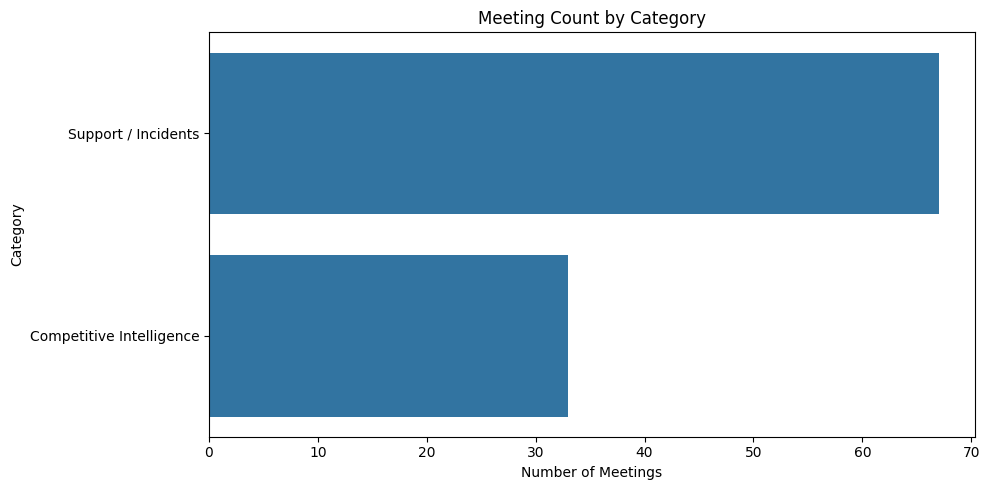

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.values, y=category_counts.index)
plt.title("Meeting Count by Category")
plt.xlabel("Number of Meetings")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [17]:
sentiment_counts = df["overall_sentiment"].value_counts()
sentiment_counts

overall_sentiment
mixed-positive    33
mixed-negative    33
very-positive     21
positive           7
negative           4
very-negative      2
Name: count, dtype: int64

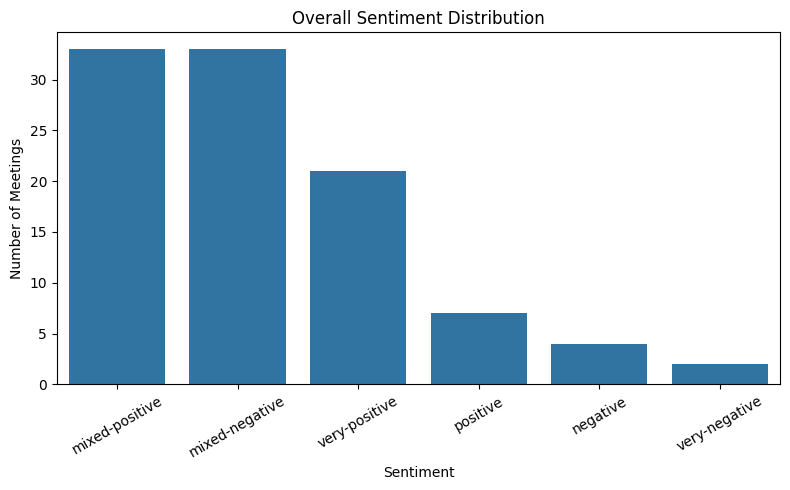

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Meetings")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [20]:
sentiment_by_category = df.groupby("category")["sentiment_score"].mean().sort_values()

sentiment_by_category

category
Competitive Intelligence    3.027273
Support / Incidents         3.607463
Name: sentiment_score, dtype: float64

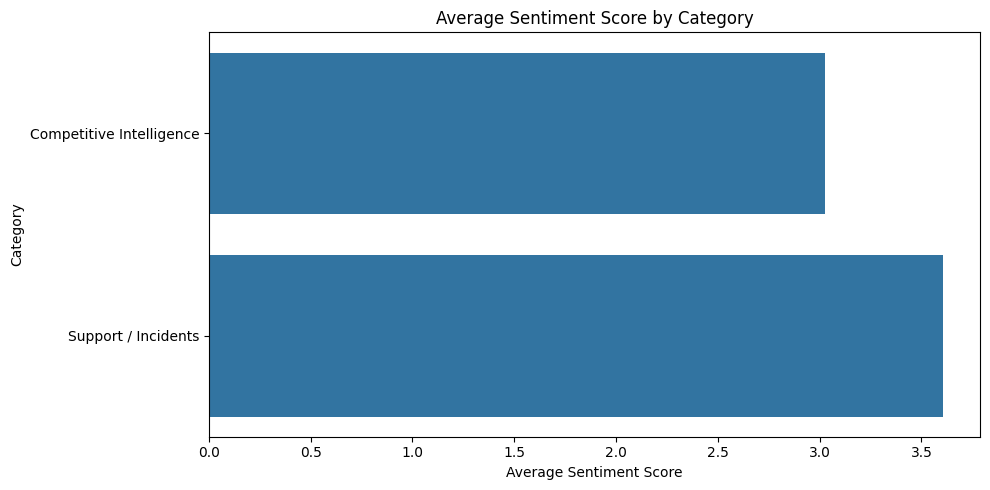

In [21]:
plt.figure(figsize=(10, 5))
sns.barplot(x=sentiment_by_category.values, y=sentiment_by_category.index)
plt.title("Average Sentiment Score by Category")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

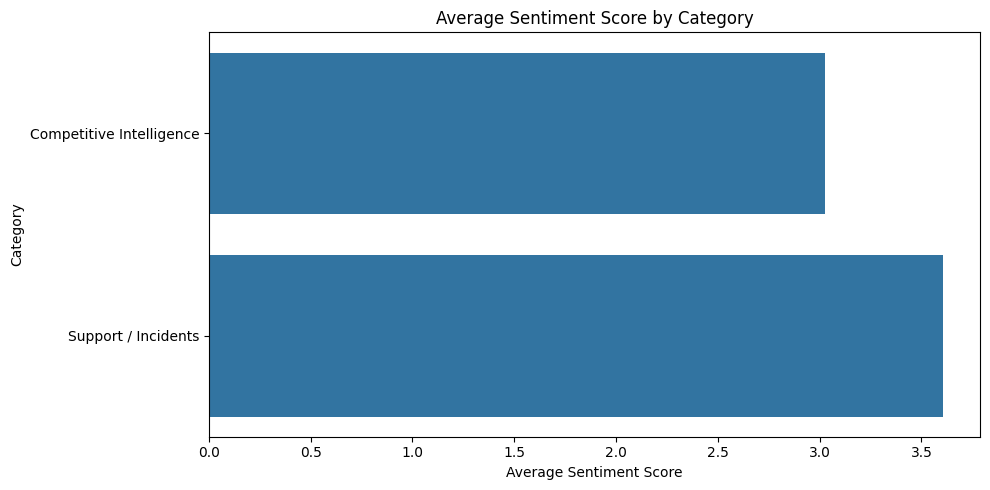

In [22]:
plt.figure(figsize=(10, 5))
sns.barplot(x=sentiment_by_category.values, y=sentiment_by_category.index)
plt.title("Average Sentiment Score by Category")
plt.xlabel("Average Sentiment Score")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [23]:
risk_keywords = [
    "churn", "renewal risk", "sla", "breach", "outage",
    "escalation", "downtime", "angry", "frustrated",
    "compliance risk", "security risk"
]

def detect_risk(text):
    text = str(text).lower()
    matched = [word for word in risk_keywords if word in text]
    return matched

df["risk_keywords"] = df["transcript_text"].apply(detect_risk)
df["risk_count"] = df["risk_keywords"].apply(len)

risky_meetings = df[df["risk_count"] > 0].sort_values("risk_count", ascending=False)

risky_meetings[["title", "category", "overall_sentiment", "sentiment_score", "risk_keywords"]].head(10)

,title,category,overall_sentiment,sentiment_score,risk_keywords
52,URGENT: Blackridge Investments - Complete Loss...,Competitive Intelligence,very-negative,1.6,"[sla, breach, outage, escalation]"
82,Support Case #6573 - Ridgeline Logistics Detec...,Support / Incidents,mixed-negative,2.1,"[sla, breach, escalation, frustrated]"
66,INCIDENT: Detect Pipeline Failure - War Room,Support / Incidents,negative,1.8,"[sla, breach, outage, escalation]"
34,Support Case #6147 - Summit Trust Detect Alert...,Support / Incidents,mixed-negative,2.4,"[outage, escalation, downtime, frustrated]"
36,Aegis / Quantum Edge - Renewal Concerns,Competitive Intelligence,mixed-negative,2.4,"[sla, breach, outage, frustrated]"
54,Aegis / Ironworks Corp - Vendor Comparison Dis...,Competitive Intelligence,mixed-negative,2.6,"[sla, outage, downtime, frustrated]"
93,Detect Reliability - 30-Day Review,Support / Incidents,mixed-negative,2.8,"[sla, breach, outage, frustrated]"
12,Detect Outage - Customer Impact Assessment,Competitive Intelligence,negative,1.8,"[churn, sla, outage, escalation]"
85,Aegis / Steelpoint Manufacturing - Contract Re...,Competitive Intelligence,mixed-negative,2.8,"[sla, outage, downtime]"
21,Support Case #6539 - Steelpoint Manufacturing ...,Support / Incidents,mixed-negative,2.4,"[outage, downtime, frustrated]"


In [24]:
risky_meetings.to_csv("high_risk_meetings.csv", index=False)

In [25]:
gap_keywords = [
    "feature gap", "product gap", "connector", "dashboard",
    "latency", "integration", "reporting", "template",
    "configuration", "roadmap"
]

def detect_product_gaps(text):
    text = str(text).lower()
    matched = [word for word in gap_keywords if word in text]
    return matched

df["product_gap_keywords"] = df["transcript_text"].apply(detect_product_gaps)
df["product_gap_count"] = df["product_gap_keywords"].apply(len)

product_gap_meetings = df[df["product_gap_count"] > 0].sort_values("product_gap_count", ascending=False)

product_gap_meetings[["title", "category", "product_gap_keywords"]].head(10)

,title,category,product_gap_keywords
0,Competitive Landscape Review,Competitive Intelligence,"[connector, integration, reporting, template, ..."
30,Aegis / Axiom Labs - Multi-Year Renewal,Competitive Intelligence,"[connector, dashboard, latency, integration, r..."
94,Aegis / Redwood Clinical - ISO 27001 Preparation,Support / Incidents,"[connector, reporting, template, configuration..."
84,Aegis / Harborview Banking - Threat Detection ...,Support / Incidents,"[integration, reporting, template, configurati..."
72,Aegis / Coastal Living Co - Protect Module Exp...,Support / Incidents,"[connector, dashboard, reporting, template, co..."
64,Aegis / Silverline Brands - Comply v2 Early Ac...,Support / Incidents,"[dashboard, integration, reporting, configurat..."
56,Aegis / Crestline Wealth - Identity Module Dep...,Support / Incidents,"[connector, integration, reporting, configurat..."
53,Aegis / Clearwater Medical - Comply v2 Deploym...,Support / Incidents,"[connector, integration, reporting, template, ..."
49,Comply v2 - Launch Readiness Review,Support / Incidents,"[integration, reporting, template, configurati..."
74,Support Case #3546 - Meridian Capital SCIM Pro...,Support / Incidents,"[connector, integration, configuration, roadmap]"


In [26]:
all_action_items = []

for _, row in df.iterrows():
    for item in row["action_items"]:
        all_action_items.append({
            "meeting_id": row["meeting_id"],
            "title": row["title"],
            "category": row["category"],
            "action_item": item
        })

action_df = pd.DataFrame(all_action_items)

print(action_df.shape)
action_df.head()

(397, 4)


,meeting_id,title,category,action_item
0,01KQ7F58A2E07B857C24624D,Competitive Landscape Review,Competitive Intelligence,Jordan Whitfield: Clean up the competitive dec...
1,01KQ7F58A2E07B857C24624D,Competitive Landscape Review,Competitive Intelligence,Tom Bradley: Review the updated deck thoroughl...
2,01KQ7F58A2E07B857C24624D,Competitive Landscape Review,Competitive Intelligence,Jordan Whitfield: Frame the LogVault connector...
3,01KQ7F58A2E07B857C24624D,Competitive Landscape Review,Competitive Intelligence,Tom Bradley: Assess engineering bandwidth feas...
4,01KQE110900B8A65D80AE694,Detect Outage - Root Cause Analysis,Support / Incidents,Mike Romano: Write a proper scope document tod...


In [27]:
action_df.to_csv("action_items.csv", index=False)

In [28]:
summary_table = df.groupby("category").agg(
    meeting_count=("meeting_id", "count"),
    avg_sentiment=("sentiment_score", "mean"),
    avg_action_items=("action_item_count", "mean"),
    avg_duration=("duration_minutes", "mean")
).reset_index()

summary_table

,category,meeting_count,avg_sentiment,avg_action_items,avg_duration
0,Competitive Intelligence,33,3.027273,3.969697,34.106061
1,Support / Incidents,67,3.607463,3.970149,28.438806


In [30]:
summary_table.to_csv("category_summary.csv", index=False)

In [31]:

df["category"].value_counts()



category
Support / Incidents         67
Competitive Intelligence    33
Name: count, dtype: int64

In [32]:
df["overall_sentiment"].value_counts()

overall_sentiment
mixed-positive    33
mixed-negative    33
very-positive     21
positive           7
negative           4
very-negative      2
Name: count, dtype: int64

In [33]:
df.groupby("category")["sentiment_score"] \
  .mean() \
  .sort_values()

category
Competitive Intelligence    3.027273
Support / Incidents         3.607463
Name: sentiment_score, dtype: float64

In [34]:
df.groupby("category")["action_item_count"] \
  .mean() \
  .sort_values(ascending=False)

category
Support / Incidents         3.970149
Competitive Intelligence    3.969697
Name: action_item_count, dtype: float64

In [35]:
df[["title", "duration_minutes", "category"]] \
  .sort_values("duration_minutes", ascending=False) \
  .head(10)

,title,duration_minutes,category
98,Aegis / Nimbus Platform - Comply v2 Preview,54.3,Support / Incidents
59,Aegis / Blackridge Investments - Renewal Discu...,54.1,Competitive Intelligence
2,Aegis / Summit Trust - Platform Concerns Discu...,53.0,Competitive Intelligence
64,Aegis / Silverline Brands - Comply v2 Early Ac...,50.3,Support / Incidents
19,Aegis / Blackridge Investments - HIPAA Complia...,49.1,Support / Incidents
57,All Hands - April Update,48.8,Competitive Intelligence
30,Aegis / Axiom Labs - Multi-Year Renewal,48.8,Competitive Intelligence
46,Aegis / Crestline Wealth - Account Review,48.7,Support / Incidents
73,Aegis / Northstar Pharma - Urgent: Detect Outa...,48.1,Competitive Intelligence
12,Detect Outage - Customer Impact Assessment,48.0,Competitive Intelligence


In [36]:
all_topics = []

for topics in df["topics"]:
    all_topics.extend(topics)

from collections import Counter

Counter(all_topics).most_common(20)

[('compliance', 23),
 ('compliance reporting', 19),
 ('renewal', 17),
 ('churn risk', 14),
 ('onboarding', 9),
 ('incident response', 8),
 ('outage', 8),
 ('product launch', 7),
 ('incident communication', 7),
 ('platform outage', 6),
 ('feature request', 6),
 ('service outage', 5),
 ('pricing', 5),
 ('product roadmap', 5),
 ('sprint planning', 5),
 ('multi-framework support', 5),
 ('outage post-mortem', 5),
 ('identity management', 5),
 ('incident review', 4),
 ('infrastructure reliability', 4)]

In [37]:
df[df["sentiment_score"] < 2.5][
    ["title", "category", "overall_sentiment", "sentiment_score"]
].head(20)

,title,category,overall_sentiment,sentiment_score
1,Detect Outage - Root Cause Analysis,Support / Incidents,mixed-negative,2.4
2,Aegis / Summit Trust - Platform Concerns Discu...,Competitive Intelligence,mixed-negative,2.4
5,Detect Outage - Escalation Bridge,Competitive Intelligence,negative,1.8
7,ESCALATION: Northstar Pharma - Detect Outage I...,Competitive Intelligence,mixed-negative,2.1
8,Support Case #3536 - Stratos Cloud LogVault In...,Support / Incidents,mixed-negative,2.4
12,Detect Outage - Customer Impact Assessment,Competitive Intelligence,negative,1.8
15,Competitive Threat Assessment - Post Outage,Competitive Intelligence,mixed-negative,2.3
21,Support Case #6539 - Steelpoint Manufacturing ...,Support / Incidents,mixed-negative,2.4
26,Support Case #3266 - Trailhead Marketplace Det...,Competitive Intelligence,very-negative,1.4
29,Aegis / Helix Data - Post-Incident Review,Competitive Intelligence,mixed-negative,2.3


In [38]:
df.sort_values("action_item_count", ascending=False)[
    ["title", "category", "action_item_count"]
].head(20)

,title,category,action_item_count
0,Competitive Landscape Review,Competitive Intelligence,4
74,Support Case #3546 - Meridian Capital SCIM Pro...,Support / Incidents,4
72,Aegis / Coastal Living Co - Protect Module Exp...,Support / Incidents,4
71,Aegis / Redwood Clinical - Product Feedback Se...,Competitive Intelligence,4
70,Detect Outage - Remediation Plan Review,Support / Incidents,4
69,Support Case #7570 - Silverline Brands Comply ...,Support / Incidents,4
68,Support Case #8749 - Coastal Living Co SAML Ce...,Support / Incidents,4
67,Aegis / Atlas Precision - Annual Review & Renewal,Competitive Intelligence,4
66,INCIDENT: Detect Pipeline Failure - War Room,Support / Incidents,4
65,Identity Team - Q2 Roadmap,Competitive Intelligence,4


In [39]:
keywords = [
    "dashboard",
    "latency",
    "connector",
    "integration",
    "reporting",
    "roadmap",
    "feature",
    "compliance",
    "security"
]

for word in keywords:
    count = df["transcript_text"].str.lower().str.contains(word).sum()
    print(word, ":", count)

dashboard : 34
latency : 13
connector : 17
integration : 38
reporting : 56
roadmap : 37
feature : 42
compliance : 61
security : 60


In [40]:
risk_words = [
    "churn",
    "renewal",
    "downtime",
    "escalation",
    "outage",
    "frustrated",
    "risk"
]

for word in risk_words:
    count = df["transcript_text"].str.lower().str.contains(word).sum()
    print(word, ":", count)

churn : 1
renewal : 31
downtime : 8
escalation : 17
outage : 46
frustrated : 14
risk : 25


In [41]:
df[["title", "speaker_count", "duration_minutes"]] \
  .sort_values("speaker_count", ascending=False) \
  .head(10)

,title,speaker_count,duration_minutes
65,Identity Team - Q2 Roadmap,5,47.6
1,Detect Outage - Root Cause Analysis,5,15.9
51,Comply v2 - Adoption Metrics Review,5,30.9
53,Aegis / Clearwater Medical - Comply v2 Deploym...,5,42.8
18,SOC 2 Audit Preparation - Internal,5,36.9
77,Competitive Response Strategy,5,34.3
17,Detect Team - Sprint Planning,5,25.1
57,All Hands - April Update,5,48.8
15,Competitive Threat Assessment - Post Outage,5,26.2
61,SOC 2 Type II - Final Review,4,40.4


In [42]:
df[[
    "sentiment_score",
    "action_item_count",
    "speaker_count",
    "duration_minutes"
]].corr()

,sentiment_score,action_item_count,speaker_count,duration_minutes
sentiment_score,1.000000,0.002810,0.120705,0.364438
action_item_count,0.002810,1.000000,0.020646,0.054407
speaker_count,0.120705,0.020646,1.000000,0.105524
duration_minutes,0.364438,0.054407,0.105524,1.000000


In [43]:
df.groupby("category").agg({
    "meeting_id": "count",
    "sentiment_score": "mean",
    "action_item_count": "mean",
    "duration_minutes": "mean"
}).sort_values("sentiment_score")

,meeting_id,sentiment_score,action_item_count,duration_minutes
category,,,,
Competitive Intelligence,33,3.027273,3.969697,34.106061
Support / Incidents,67,3.607463,3.970149,28.438806
